<a href="https://colab.research.google.com/github/nitindavegit/Deep-Learning/blob/main/pytorch08_ann_fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [83]:
# set random seed value
torch.manual_seed(42)

In [84]:
df = pd.read_csv('/content/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


### Let's see how the dataset looks like

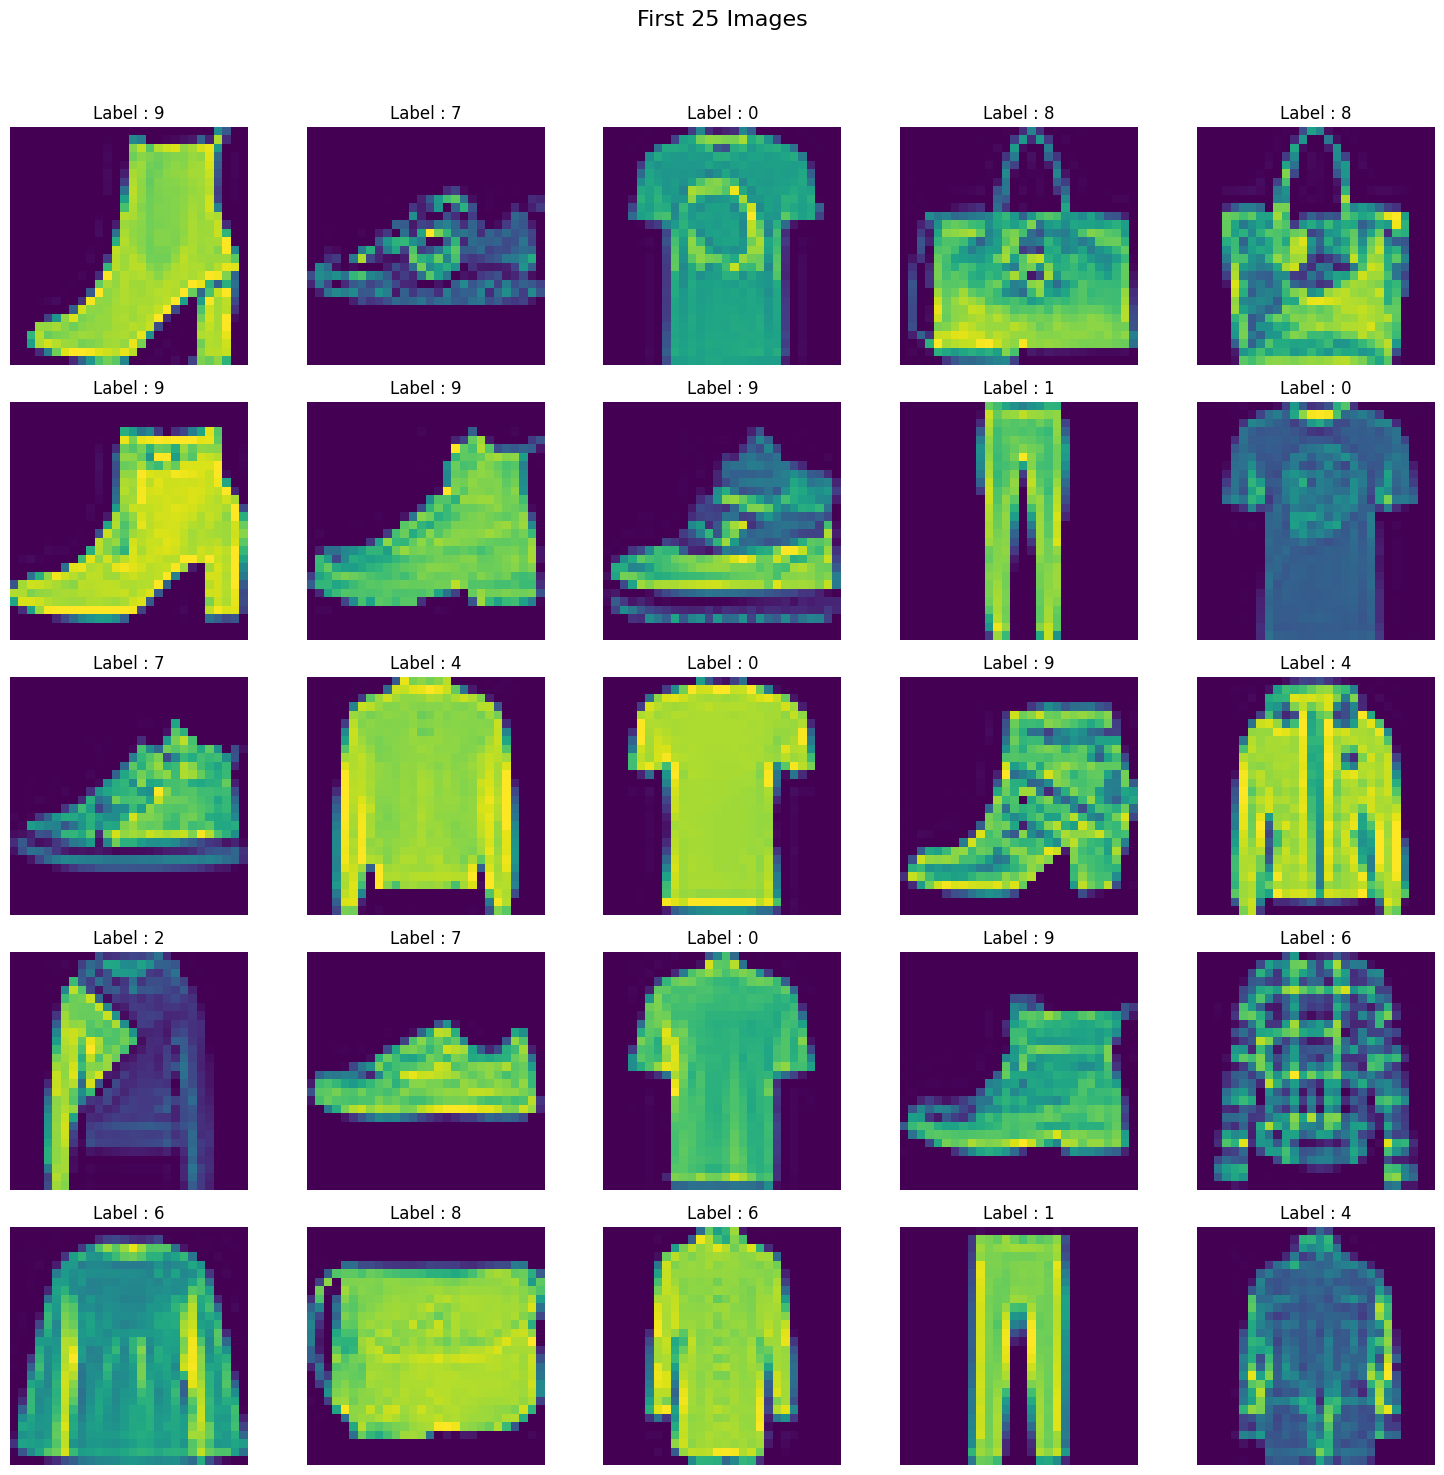

In [85]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(5,5,figsize=(15,15))
fig.suptitle("First 25 Images", fontsize=16)

# plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28) # reshape to (28,28)
  ax.imshow(img)    # Display in greyscale
  ax.axis('off') # remove the axis
  ax.set_title(f"Label : {df.iloc[i,0]}")   # Show the label

plt.tight_layout(rect=[0,0,1,0.95])   # Adjust layout to fit title
plt.show()

### Applying train test split

In [86]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

### Since the pixel values lies between 0 to 255, it is good to make sure all your features lies between the same range, therefore dividing X and y by 255 to make sure it lies between 0 to 1

In [88]:
# Scaling the features
X_train = X_train / 255.0
X_test = X_test / 255.0

In [89]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
3897,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5628,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.003922,...,0.356863,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1756,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2346,0.0,0.0,0.0,0.0,0.0,0.003922,0.000000,0.000000,0.0,0.000000,...,0.003922,0.000000,0.000000,0.000000,0.000000,0.254902,0.090196,0.000000,0.0,0.0
2996,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.262745,...,0.533333,0.470588,0.286275,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5191,0.0,0.0,0.0,0.0,0.0,0.000000,0.003922,0.000000,0.0,0.200000,...,0.000000,0.000000,0.003922,0.000000,0.031373,0.258824,0.000000,0.000000,0.0,0.0
5226,0.0,0.0,0.0,0.0,0.0,0.000000,0.011765,0.003922,0.0,0.000000,...,0.439216,0.474510,0.474510,0.027451,0.000000,0.003922,0.000000,0.000000,0.0,0.0
5390,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [90]:
X_test

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
1782,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
3917,0.0,0.0,0.0,0.0,0.0,0.000000,0.164706,0.176471,0.0,0.0,...,0.521569,0.345098,0.117647,0.0,0.000000,0.000000,0.000000,0.003922,0.0,0.0
221,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2135,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.133333,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5224,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2543,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1773,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2846,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5799,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.176471,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0


### Creating CustomDataset Class

In [91]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features.values, dtype=torch.float32)     # COnverting it to numpy array and then to  pytorch tensors while providing features and labels
    self.labels = torch.tensor(labels.values, dtype=torch.long)            # COnverting it to numpy array and then to pytorch tensors while providing features and labels

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

In [92]:
# Creating 2 different datasets for training and validation

train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [93]:
train_dataset[5]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3608,
         0.7765, 0.5765, 0.2510, 0.1529, 0.1412, 0.2157, 0.3412, 0.4118, 0.6588,
         0.6471, 0.1882, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3765, 0.9922,
         0.8588, 0.8314, 0.9725, 1.0000, 1.0000, 1.0000, 0.8118, 0.8471, 0.9961,
         0.8471, 0.8275, 0.8627, 0.9373, 0.1490, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1490, 0.8706,
         0.8078, 0.7922, 0.7804, 0.7686, 0.7451, 0.7608, 0.8000, 0.7373, 0.7490,
         0.7451, 0.7647, 0.7922, 0.7843, 0.8353, 0.8039, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6314,
         0.8667, 0.7961, 0.8118, 0.8039, 0.8078, 0.8000, 0.7922, 0.7922, 0.8157,
         0.8275, 0.8275, 0.8196, 0.7804, 0.8118, 0.7804, 0.8784, 0.4941, 0.0000,
         0.0000, 0.0000, 0.0

In [94]:
# creating 2 different dataloaders for training and validation

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False )

## Creating Neural Network class

In [95]:
class MyNN(nn.Module):

  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self, features):
    out = self.model(features)
    return out


In [96]:
# learning rate and no. of epochs
learning_rate = 0.1
epochs = 100

### Creating usual training pipeline

In [97]:
# instantiate the model
model = MyNN(X_train.shape[1])

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [98]:
len(train_dataloader)

150

In [99]:
# training loop
for epoch in range(epochs):    # loop interates 100 times

  total_epoch_loss = 0
  for batch_features, batch_labels in train_dataloader:    # loop iterates 200 times

    # forward pass
    y_pred = model(batch_features)

    # loss calculation
    loss = criterion(y_pred , batch_labels)

    # gradient reset
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # parameters update
    optimizer.step()

    total_epoch_loss = loss.item()

  avg_loss = total_epoch_loss / len(train_dataloader)
  print(f"Epoch : {epoch + 1}, Loss : {avg_loss}")

Epoch : 1, Loss : 0.005126576423645019
Epoch : 2, Loss : 0.00375916322072347
Epoch : 3, Loss : 0.0042385609944661454
Epoch : 4, Loss : 0.0029633253812789916
Epoch : 5, Loss : 0.003206270734469096
Epoch : 6, Loss : 0.0030983052651087444
Epoch : 7, Loss : 0.0032340975602467856
Epoch : 8, Loss : 0.001714307467142741
Epoch : 9, Loss : 0.001916703979174296
Epoch : 10, Loss : 0.001115820308526357
Epoch : 11, Loss : 0.003248592217763265
Epoch : 12, Loss : 0.0031151171525319417
Epoch : 13, Loss : 0.004168589909871419
Epoch : 14, Loss : 0.004701868295669555
Epoch : 15, Loss : 0.00212175985177358
Epoch : 16, Loss : 0.002099879185358683
Epoch : 17, Loss : 0.0011420217156410217
Epoch : 18, Loss : 0.0023634107907613117
Epoch : 19, Loss : 0.002996842662493388
Epoch : 20, Loss : 0.0021595752239227297
Epoch : 21, Loss : 0.0016800743341445924
Epoch : 22, Loss : 0.0019670456647872927
Epoch : 23, Loss : 0.0012778977553049723
Epoch : 24, Loss : 0.0009076084693272909
Epoch : 25, Loss : 0.000856918096542358

### Model evaluation

In [100]:
model.eval()

total = 0
correct = 0


with torch.no_grad():
  for batch_features, batch_labels in test_dataloader:

    # forward pass
   y_pred =  model(batch_features)     # (32,10)
   _, predicted = torch.max(y_pred, 1)
   total = total + batch_labels.shape[0]

   correct = correct + (predicted == batch_labels).sum().item()          # .float().mean()


print(f"Accuracy : {correct / total}")




Accuracy : 0.8325


In [101]:
a = torch.tensor([[1,2,3],[7,1,2]])

In [102]:
a.shape

torch.Size([2, 3])

In [103]:
value, index = torch.max(a,1)

In [104]:
print(value)
print(index)

tensor([3, 7])
tensor([2, 0])
